In [ ]:
# ============================================================
# STEP 0: INSTALL & MOUNT GOOGLE DRIVE
# ============================================================

!unzip -q anatomy_dataset.zip -d /content

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install albumentations

In [ ]:
# ============================================================
# STEP 1: IMPORTS & CONFIG
# ============================================================
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================= PATHS =================
DATASET_ROOT = "/content/DATASET"
MODEL_DIR = "/content/SWIN_UNETR_MODEL"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = f"{MODEL_DIR}/best_swin_unetr.pth"

# ================= TRAINING CONFIG =================
NUM_CLASSES = 8
BATCH_SIZE = 1
LR = 2e-5
EPOCHS = 50
PATIENCE = 7
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [ ]:
# ============================================================
# STEP 2: DATASET CLASS
# ============================================================
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

        if augment:
            self.tf = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                ),
                ToTensorV2()
            ])
        else:
            self.tf = A.Compose([
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                ),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        img = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

        img = cv2.resize(img, (224,224))
        mask = cv2.resize(mask, (224,224), interpolation=cv2.INTER_NEAREST)

        aug = self.tf(image=img, mask=mask)
        return aug["image"], aug["mask"].long()

In [ ]:
!pip install timm

In [ ]:
# ============================================================
# STEP 3: SWIN-UNETR MODEL
# ============================================================

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SwinUNETR(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # -------- Swin Transformer Encoder --------
        self.encoder = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            features_only=True
        )

        enc_ch = self.encoder.feature_info.channels()
        # [128, 256, 512, 1024]

        # -------- Decoder --------
        self.dec4 = ConvBlock(enc_ch[3], 512)
        self.dec3 = ConvBlock(512 + enc_ch[2], 256)
        self.dec2 = ConvBlock(256 + enc_ch[1], 128)
        self.dec1 = ConvBlock(128 + enc_ch[0], 64)

        self.out = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        feats = self.encoder(x)
        feats = [f.permute(0, 3, 1, 2).contiguous() for f in feats]

        f1, f2, f3, f4 = feats

        d4 = self.dec4(f4)

        d3 = F.interpolate(d4, size=f3.shape[2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, f3], dim=1))

        d2 = F.interpolate(d3, size=f2.shape[2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, f2], dim=1))

        d1 = F.interpolate(d2, size=f1.shape[2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, f1], dim=1))

        out = self.out(d1)
        out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)

        return out

In [ ]:
# ============================================================
# STEP 4: LOSSES (HYBRID nnU-Net – CORRECT)
# ============================================================

class_weights = torch.tensor(
    [1.0, 1.5, 2.0, 1.8, 4.0, 3.5, 2.0, 1.8],  # ↑ SI
    device=device
)

# ================= LOSSES (STABLE HYBRID VERSION) =================

seg_bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, gt, eps=1e-6):
    pred = torch.sigmoid(pred)
    inter = (pred * gt).sum((2,3))
    union = pred.sum((2,3)) + gt.sum((2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

def main_loss(pred, gt):
    return dice_loss(pred, gt) + seg_bce_loss(pred, gt)

def aux_loss(pred, gt):
    return dice_loss(pred, gt)

In [ ]:
# ============================================================
# STEP 5: LOAD DATA
# ============================================================
train_ds = SegDataset(
    f"{DATASET_ROOT}/TRAIN/IMAGE",
    f"{DATASET_ROOT}/TRAIN/MASK",
    augment=True
)

val_ds = SegDataset(
    f"{DATASET_ROOT}/VALIDATION/IMAGE",
    f"{DATASET_ROOT}/VALIDATION/MASK"
)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2)


In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
# ============================================================
# STEP 6: TRAINING LOOP (SWIN-UNETR)
# ============================================================

from torch.amp import autocast, GradScaler

model = SwinUNETR(num_classes=NUM_CLASSES).to(device)

# ---- Freeze encoder initially ----
for p in model.encoder.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=1e-4
)

scaler = GradScaler(enabled=torch.cuda.is_available())

best_val_loss = float("inf")
wait = 0

history = {"train_loss": [], "val_loss": []}
dice_history = {"small_intestine": [], "stomach": []}

def dice_per_class(pred, target, eps=1e-5):
    pred = (torch.sigmoid(pred) > 0.5)
    inter = (pred & target.bool()).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return (2 * inter + eps) / (union + eps)

# ---------------- TRAINING ----------------
for epoch in range(EPOCHS):

    print(f"\n================ Epoch {epoch+1}/{EPOCHS} ================")

    # 🔓 Unfreeze Swin after warm-up
    if epoch == 10:
        print("🔓 Unfreezing Swin encoder")
        for p in model.encoder.parameters():
            p.requires_grad = True

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    for x, seg_gt in tqdm(train_loader, desc="Training", leave=False):
        x = x.to(device)
        seg_gt = seg_gt.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            out = model(x)
            seg_gt_oh = torch.nn.functional.one_hot(
                seg_gt, NUM_CLASSES
            ).permute(0,3,1,2).float()

            loss = main_loss(out, seg_gt_oh)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0
    dice_si, dice_st = [], []

    with torch.no_grad():
        for x, seg_gt in tqdm(val_loader, desc="Validation", leave=False):
            x = x.to(device)
            seg_gt = seg_gt.to(device)

            with autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                out = model(x)
                seg_gt_oh = torch.nn.functional.one_hot(
                    seg_gt, NUM_CLASSES
                ).permute(0,3,1,2).float()

                loss = main_loss(out, seg_gt_oh)
                val_loss += loss.item()

                dice_vals = dice_per_class(out, seg_gt_oh)
                if seg_gt_oh[:,5].sum() > 0:
                    dice_si.append(dice_vals[:,5].mean().item())
                if seg_gt_oh[:,7].sum() > 0:
                    dice_st.append(dice_vals[:,7].mean().item())

    val_loss /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    dice_history["small_intestine"].append(np.mean(dice_si) if dice_si else 0.0)
    dice_history["stomach"].append(np.mean(dice_st) if dice_st else 0.0)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"SI Dice: {dice_history['small_intestine'][-1]:.3f} | "
        f"ST Dice: {dice_history['stomach'][-1]:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        wait = 0
        print("✅ Model saved")
    else:
        wait += 1
        print(f"⚠️ No improvement ({wait}/{PATIENCE})")
        if wait >= PATIENCE:
            print("⛔ Early stopping triggered")
            break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]


================ Epoch 1/50 ================


Epoch 1 | Train Loss: 1.2034 | Val Loss: 1.1167 | SI Dice: 0.024 | ST Dice: 0.006
✅ Model saved

================ Epoch 2/50 ================


Epoch 2 | Train Loss: 1.0652 | Val Loss: 1.0092 | SI Dice: 0.000 | ST Dice: 0.504
✅ Model saved

================ Epoch 3/50 ================


...

Epoch 43 | Train Loss: 0.5957 | Val Loss: 0.6449 | SI Dice: 0.869 | ST Dice: 0.862
⚠️ No improvement (3/7)

================ Epoch 44/50 ================


Epoch 44 | Train Loss: 0.5912 | Val Loss: 0.6482 | SI Dice: 0.872 | ST Dice: 0.869
⚠️ No improvement (4/7)

================ Epoch 45/50 ================


Epoch 45 | Train Loss: 0.5901 | Val Loss: 0.6433 | SI Dice: 0.871 | ST Dice: 0.873
⚠️ No improvement (5/7)

================ Epoch 46/50 ================


Epoch 46 | Train Loss: 0.5897 | Val Loss: 0.6443 | SI Dice: 0.872 | ST Dice: 0.880
⚠️ No improvement (6/7)

================ Epoch 47/50 ================


Epoch 47 | Train Loss: 0.5891 | Val Loss: 0.6445 | SI Dice: 0.867 | ST Dice: 0.867
⚠️ No improvement (7/7)
⛔ Early stopping triggered


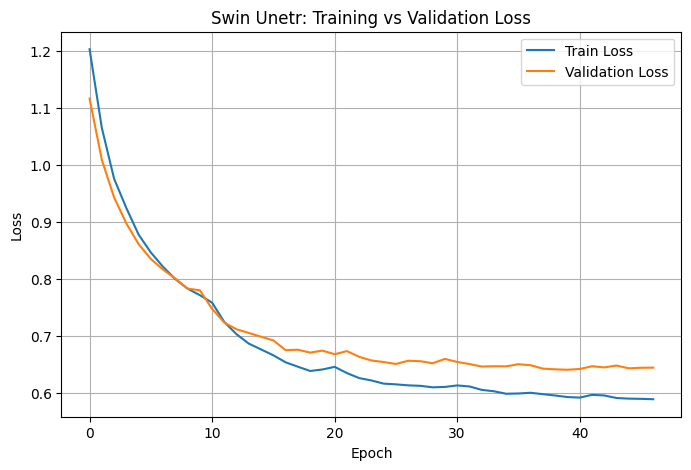

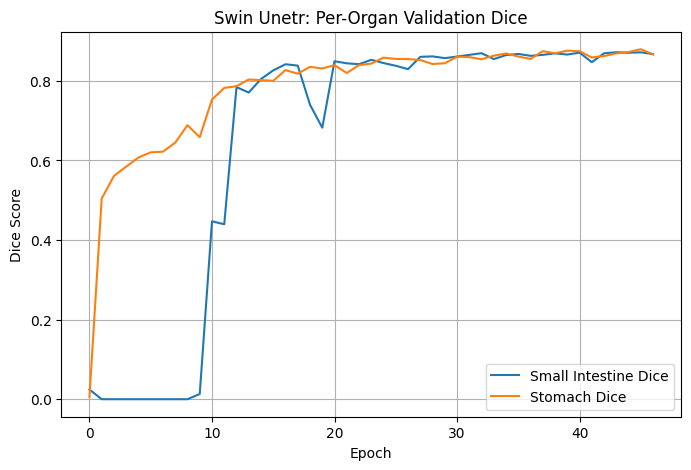

In [ ]:
  # ============================================================
# STEP 7: TRAINING CURVES (FINAL)
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin Unetr: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(dice_history["small_intestine"], label="Small Intestine Dice")
plt.plot(dice_history["stomach"], label="Stomach Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Swin Unetr: Per-Organ Validation Dice")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# STEP 8: TESTING (DEEPLABV3 – FIXED)
# ============================================================

model = SwinUNETR(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ SwinUnetr model loaded correctly")

✅ SwinUnetr model loaded correctly


In [ ]:
# ---- Class-wise thresholds (important for rare organs) ----
thresholds = {
    1: 0.35,  # abdominal_wall
    2: 0.35,  # colon
    3: 0.35,  # liver
    4: 0.25,  # pancreas
    5: 0.30,  # small_intestine
    6: 0.35,  # spleen
    7: 0.40,  # stomach
}

In [ ]:
# ---- Dice storage ----
dice_scores = {i: [] for i in range(NUM_CLASSES)}

def dice_per_class(pred, target, eps=1e-5):
    inter = (pred & target).sum((2,3))
    union = pred.sum((2,3)) + target.sum((2,3))
    return (2 * inter + eps) / (union + eps)

In [ ]:
# ============================================================
# STEP 7.5: TEST DATASET & LOADER (REQUIRED)
# ============================================================

test_ds = SegDataset(
    img_dir=f"{DATASET_ROOT}/TEST/IMAGE",
    mask_dir=f"{DATASET_ROOT}/TEST/MASK",
    augment=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,          # IMPORTANT for segmentation
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ test_loader created successfully")

✅ test_loader created successfully


In [ ]:
# ---- Testing loop ----

# ---- Metric accumulators (pixel-wise) ----
tp = torch.zeros(NUM_CLASSES)
fp = torch.zeros(NUM_CLASSES)
fn = torch.zeros(NUM_CLASSES)
tn = torch.zeros(NUM_CLASSES)

with torch.no_grad():
    for x, seg_gt in tqdm(test_loader, desc="Testing"):
        x = x.to(device)
        seg_gt = seg_gt.to(device)

        seg_out = model(x)
        prob = torch.softmax(seg_out, dim=1)
        pred = torch.argmax(prob, dim=1)

        pred_oh = F.one_hot(pred, NUM_CLASSES).permute(0,3,1,2).bool()
        gt_oh   = F.one_hot(seg_gt, NUM_CLASSES).permute(0,3,1,2).bool()

        for c in range(NUM_CLASSES):
            tp[c] += (pred_oh[:, c] & gt_oh[:, c]).sum().cpu()
            fp[c] += (pred_oh[:, c] & ~gt_oh[:, c]).sum().cpu()
            fn[c] += (~pred_oh[:, c] & gt_oh[:, c]).sum().cpu()
            tn[c] += (~pred_oh[:, c] & ~gt_oh[:, c]).sum().cpu()

            if gt_oh[:, c].sum() > 0:
                dice_scores[c].append(
                    (2 * tp[c]) / (2 * tp[c] + fp[c] + fn[c] + 1e-6)
                )

Testing: 100%|██████████| 72/72 [00:03<00:00, 21.58it/s]


In [ ]:
# ---- Print results ----
print("\n===== TEST RESULTS (Presence-aware Dice) =====")

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

for c, name in enumerate(CLASS_NAMES):
    if len(dice_scores[c]) > 0:
        print(f"{name:20s} : {np.mean(dice_scores[c]):.4f}")
    else:
        print(f"{name:20s} : N/A (not present)")


===== TEST RESULTS (Presence-aware Dice) =====
background           : 0.9812
abdominal_wall       : 0.9474
colon                : 0.8549
liver                : 0.8994
pancreas             : 0.7276
small_intestine      : 0.9572
spleen               : 0.8380
stomach              : 0.9326


In [ ]:
eps = 1e-7

precision = tp / (tp + fp + eps)
recall    = tp / (tp + fn + eps)
dice_all  = (2 * tp) / (2 * tp + fp + fn + eps)
iou       = tp / (tp + fp + fn + eps)
accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)
f1        = dice_all  # Dice == F1 for segmentation

print("\n===== FULL SEGMENTATION EVALUATION =====\n")
print(f"{'Class':20s} | Acc | Prec | Recall | Dice | IoU")
print("-" * 70)

for c, name in enumerate(CLASS_NAMES):
    print(
        f"{name:20s} | "
        f"{accuracy[c]:.3f} | "
        f"{precision[c]:.3f} | "
        f"{recall[c]:.3f} | "
        f"{dice_all[c]:.3f} | "
        f"{iou[c]:.3f}"
    )

print("\n===== OVERALL MODEL PERFORMANCE =====")
print(f"Mean Accuracy : {accuracy[1:].mean():.4f}")
print(f"Mean Precision: {precision[1:].mean():.4f}")
print(f"Mean Recall   : {recall[1:].mean():.4f}")
print(f"Mean Dice     : {dice_all[1:].mean():.4f}")
print(f"Mean IoU      : {iou[1:].mean():.4f}")



===== FULL SEGMENTATION EVALUATION =====

Class                | Acc | Prec | Recall | Dice | IoU
----------------------------------------------------------------------
background           | 0.974 | 0.982 | 0.985 | 0.983 | 0.967
abdominal_wall       | 0.991 | 0.931 | 0.957 | 0.944 | 0.894
colon                | 0.995 | 0.879 | 0.828 | 0.853 | 0.744
liver                | 0.995 | 0.947 | 0.882 | 0.913 | 0.841
pancreas             | 0.997 | 0.603 | 0.516 | 0.556 | 0.385
small_intestine      | 1.000 | 0.955 | 0.939 | 0.947 | 0.900
spleen               | 0.999 | 0.955 | 0.885 | 0.919 | 0.850
stomach              | 0.991 | 0.947 | 0.933 | 0.940 | 0.886

===== OVERALL MODEL PERFORMANCE =====
Mean Accuracy : 0.9955
Mean Precision: 0.8883
Mean Recall   : 0.8487
Mean Dice     : 0.8675
Mean IoU      : 0.7856


In [ ]:
# ============================================================
# STEP 9: SINGLE IMAGE TESTING (DEEPLABV3 – FIXED)
# ============================================================

import matplotlib.pyplot as plt

CLASS_NAMES = [
    "background",
    "abdominal_wall",
    "colon",
    "liver",
    "pancreas",
    "small_intestine",
    "spleen",
    "stomach"
]

COLORS = {
    1: (255, 0, 0),
    2: (0, 255, 0),
    3: (0, 0, 255),
    4: (255, 255, 0),
    5: (255, 0, 255),
    6: (0, 255, 255),
    7: (255, 165, 0),
}

COLOR_NAMES = {
    1: "Red",        # abdominal_wall
    2: "Green",      # colon
    3: "Blue",       # liver
    4: "Yellow",     # pancreas
    5: "Magenta",    # small_intestine
    6: "Cyan",       # spleen
    7: "Orange",     # stomach
}

# ---- rebuild model EXACTLY like Step 8 ----
model = SwinUNETR(NUM_CLASSES)
model = model.to(device)

state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.eval()

def test_single_image(image_path, model, device):
    model.eval()

    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    # 🔑 SAME normalization as training
    img_tensor = (
        torch.from_numpy(img_resized)
        .permute(2, 0, 1)
        .float()
        / 255.0
    )

    img_tensor = (img_tensor - 0.5) / 0.5   # match Albumentations Normalize
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(img_tensor)
        prob = torch.sigmoid(out)[0]

    overlay = img_resized.copy()
    detected = []

    for c in range(1, NUM_CLASSES):
        th = thresholds.get(c, 0.3)
        mask = (prob[c] > th).cpu().numpy()

        if mask.sum() > 20:
            detected.append((CLASS_NAMES[c], COLOR_NAMES[c]))
            overlay[mask] = (
                0.6 * overlay[mask] + 0.4 * np.array(COLORS[c])
            )

    print("Max probability per class:")
    for c in range(1, NUM_CLASSES):
        print(CLASS_NAMES[c], float(prob[c].max()))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_resized)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay.astype(np.uint8))
    plt.title("Predicted Segmentation")
    plt.axis("off")
    plt.show()

    print("🧠 Detected Anatomies:")
    for name, color in detected:
        print(f" - {name} ({color})")

Max probability per class:
abdominal_wall 1.0
colon 0.0008088817703537643
liver 0.0010569088626652956
pancreas 0.000783691939432174
small_intestine 0.002668364904820919
spleen 0.0010900585912168026
stomach 1.0


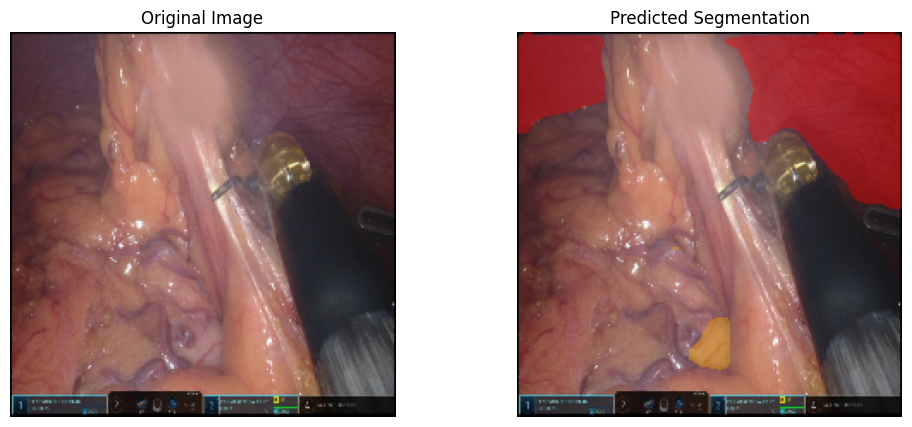

🧠 Detected Anatomies:
 - abdominal_wall (Red)
 - stomach (Orange)


In [ ]:
# ---- Run ----
test_single_image(
    image_path="/content/DATASET/TEST/IMAGE/img013.png",
    model=model,
    device=device
)